In [32]:
import pandas as pd
import numpy as np
import json
import os
from lifelines import CoxPHFitter
import random
import warnings
from miner import *
from miner.miner import *
import inspect

# Define relevant paths, to be reused multiple times
data_dir    = r"D:\School\IITD\General\GBM_new\miner_input_data"
matrices_dir = r"D:\School\IITD\General\GBM_new\miner_output\output_matrices"
jsons_dir   = r"D:\School\IITD\General\GBM_new\miner_output\output_jsons"
output_dir = r"D:\School\IITD\General\GBM_new\miner_output"

# For cox regression to determine disease-relevance, we need 3 inputs: survival status, survival time (unlike GuanRank doesn't need days) and eigengenes
eigengenes = pd.read_csv(r"D:\School\IITD\General\GBM_new\miner_output\output_matrices\eigengenes.csv", index_col=0)
clinical = pd.read_csv(r"D:\School\IITD\General\GBM_new\miner_input_data\clinical_data.csv", index_col=0)

# Find the number of common patients and align both datasets so that they only include common patients. 
# Here overlap is 100% so this is redundant but a good practice
common_patients = list(set(eigengenes.columns) & set(clinical.index))
eigen_aligned = eigengenes.loc[:, common_patients].T  # patients x regulons
clinical_aligned = clinical.loc[common_patients, ['OS_MONTHS', 'OS_STATUS']]

print(f"eigengenes shape: {eigengenes.shape}")
print(f"clinical shape: {clinical.shape}")
print(f"common patients: {len(common_patients)}")

eigengenes shape: (4504, 547)
clinical shape: (547, 2)
common patients: 547


In [2]:
# Testing Cox on random regulon:

# selected regulon: 2841
# HR: 1.1730
# p-value: 0.0009 (should be disease relevant)

regulon = 2841
df_cox = clinical_aligned.copy()
df_cox['eigengene'] = eigen_aligned[regulon].values
df_cox = df_cox.dropna()

cph = CoxPHFitter()
cph.fit(df_cox, duration_col='OS_MONTHS', event_col='OS_STATUS')
print(f"HR: {cph.hazard_ratios_['eigengene']:.4f}")
print(f"p-value: {cph.summary.loc['eigengene', 'p']:.4f}")

HR: 1.2082
p-value: 0.0212


In [373]:
# Selected regulon: 2841
# HR: 1.2082
# p-value: 0.0212


In [3]:
# Checking genes present in regulon 2841
import json
with open(os.path.join(jsons_dir, "regulons.json")) as f:
    regulon_modules = json.load(f)

#print(f"genes in regulon 2841:")
#print(regulon_modules['2841'])
#print(f"number of genes: {len(regulon_modules['2841'])}")

# Above returns genes as Ensembl IDs, to see gene names we use MINER's inbuilt mapping:

miner_dir = r"C:\Users\Amogh Kukreja\AppData\Roaming\Python\Python313\site-packages\miner"  
idmap_path = os.path.join(miner_dir, "data", "identifier_mappings.txt")
idmap = pd.read_csv(idmap_path, sep="\t", header=0)

# idmap has source data for multiple biomolecules (proteins, mRNA, genes)
# We filter to genes and only keep 2 columns: Preferred Name (Gene name) and Name (Ensembl ID)
gene_name_map = idmap[idmap['Source'] == 'Gene Name'][['Preferred_Name', 'Name']]

# Creates a mapping dict {name: Ensembl}
symbol_to_ensembl = dict(zip(gene_name_map['Name'], gene_name_map['Preferred_Name']))

# Reverses dict
ensembl_to_symbol = {v: k for k, v in symbol_to_ensembl.items()}

genes_2841 = regulon_modules['2841']
symbols_2841 = [ensembl_to_symbol.get(g, g) for g in genes_2841]
print(symbols_2841)

# ['OSBPL3', 'PPARGC1A', 'ACSL3', 'ANXA1', 'SACS', 'STK17A']

['OSBPL3', 'PPARGC1A', 'ACSL3', 'ANXA1', 'SACS', 'STK17A']


In [65]:
# Now running Cox regression on regulons, 500 at a time
warnings.filterwarnings('ignore')

cox_results = []

# Each element is 0, 1, 2, 3... as the eigengenes are indexed only by a simple number
regulon_list = eigengenes.index.tolist()

# Processes 500 regulons at a time 
batch_size = 500

for batch_start in range(0, len(regulon_list), batch_size):
    
    batch = regulon_list[batch_start:batch_start+batch_size]          # Changing batch of 500 regulons for each iteration
    
    for regulon in batch:
        
        df_cox = clinical_aligned.copy()
        df_cox['eigengene'] = eigen_aligned[regulon].values
        df_cox = df_cox.dropna()                                      # Drops NaN values after alignment so that no dimension mismatch
        
        try:
        
            cph = CoxPHFitter()
            cph.fit(df_cox, duration_col='OS_MONTHS', event_col='OS_STATUS')
            hr = cph.hazard_ratios_['eigengene']
            p = cph.summary.loc['eigengene', 'p']
            cox_results.append({'regulon': regulon, 'HR': hr, 'p_value': p})
            
        except Exception:
            cox_results.append({'regulon': regulon, 'HR': np.nan, 'p_value': np.nan})
    
    print(f"completed {min(batch_start+batch_size, len(regulon_list))}/{len(regulon_list)} regulons")

cox_df = pd.DataFrame(cox_results).set_index('regulon')
cox_df.to_csv(os.path.join(output_dir, "regulon_cox_results.csv"))

print(f"\ntotal regulons tested: {len(cox_df)}")
print(f"significant (p<=0.05): {(cox_df['p_value']<=0.05).sum()}")
print(f"high risk (HR>1, p<=0.05): {((cox_df['HR']>1) & (cox_df['p_value']<=0.05)).sum()}")
print(f"low risk (HR<1, p<=0.05): {((cox_df['HR']<1) & (cox_df['p_value']<=0.05)).sum()}")


completed 500/4504 regulons
completed 1000/4504 regulons
completed 1500/4504 regulons
completed 2000/4504 regulons
completed 2500/4504 regulons
completed 3000/4504 regulons
completed 3500/4504 regulons
completed 4000/4504 regulons
completed 4500/4504 regulons
completed 4504/4504 regulons

total regulons tested: 4504
significant (p<=0.05): 1310
high risk (HR>1, p<=0.05): 1196
low risk (HR<1, p<=0.05): 114


In [70]:
disease_relevant = cox_df[cox_df['p_value'] <= 0.05].index.tolist()
print(len(disease_relevant))

# save
cox_df['disease_relevant'] = cox_df['p_value'] <= 0.05
cox_df.to_csv(os.path.join(output_dir, "regulon_cox_results.csv"))
pd.Series(disease_relevant).to_csv(
    os.path.join(output_dir, "disease_relevant_regulons.csv"), 
    index=False, header=False
)
print("saved disease_relevant_regulons.csv")

1310
saved disease_relevant_regulons.csv


In [ ]:
 # total regulons tested: 4504
# disease-relevant (p<=0.05): 1310; paper had 1083. 1310/4504 is roughly equivalent to 1083/3797
# high risk (HR>1, p<=0.05): 1196
# low risk (HR<1, p<=0.05): 114

In [8]:
# We must now map probes to Entrez Gene IDs; this is done in R
# Now gravendeel_expression has Entrez IDs as index
grav = pd.read_csv("D:/School/IITD/General/GBM_new/output/gravendeel_expression.csv", index_col=0)
print(grav.index[:5].tolist())
print("grav.index type:", grav.index.dtype)
print("grav.index sample:", grav.index[:5].tolist())
print(grav.shape)

[1, 10, 100, 1000, 10000]
grav.index type: object
grav.index sample: [1, 10, 100, 1000, 10000]
(17589, 284)


C:\Users\Amogh Kukreja\AppData\Local\Temp\ipykernel_27728\3934919181.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  grav = pd.read_csv("D:/School/IITD/General/GBM_new/output/gravendeel_expression.csv", index_col=0)


In [10]:
# Converting Ensembl to Entrez:
url = "https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Homo_sapiens.gene_info.gz"
gene_info = pd.read_csv(url, sep='\t', compression='gzip', usecols=['GeneID', 'dbXrefs'])
regulon_df = pd.read_csv(os.path.join(matrices_dir, "regulonDf.csv"), index_col=0)

# Parse Ensembl ID from dbXrefs column
def extract_ensembl(xrefs):
    if pd.isna(xrefs):
        return None
    for x in xrefs.split('|'):
        if x.startswith('Ensembl:'):              # xrefs column has rows of the format "Ensembl: ENSEMBL_ID | ... | ..."
            return x.replace('Ensembl:', '')      # Extracting Ensembl ID if present
    return None
    
# Ensembl column of gene_info dataframe is the dbXrefs column with the function applied to it (similar to map)
gene_info['Ensembl'] = gene_info['dbXrefs'].apply(extract_ensembl)

# Drops any NaN values
gene_info = gene_info.dropna(subset=['Ensembl'])

# Packs it into a dictionary 
ensembl_to_entrez = dict(zip(gene_info['Ensembl'], gene_info['GeneID'].astype(str)))

print("Mapped:", len(ensembl_to_entrez))

# Check overlap
regulon_entrez = regulon_df['Gene'].map(ensembl_to_entrez)
overlap = set(regulon_entrez.dropna()) & set(grav.index.astype(str))
print("Regulon-Gravendeel overlap:", len(overlap))

Mapped: 38209
Regulon-Gravendeel overlap: 5583


In [396]:
# Reverse ensembl_to_entrez to get entrez_to_symbol
entrez_to_symbol = {}
for ensembl, entrez in ensembl_to_entrez.items():
    symbol = ensembl_to_symbol.get(ensembl, None)
    if symbol:
        entrez_to_symbol[str(entrez)] = symbol

print(f"Entrez→symbol mappings: {len(entrez_to_symbol)}")

# Reload grav cleanly
grav = pd.read_csv("D:/School/IITD/General/GBM_new/output/gravendeel_expression.csv", index_col=0)
grav.index = grav.index.astype(str)
grav.index = grav.index.map(entrez_to_symbol)
grav = grav[grav.index.notna()]

print(f"Gravendeel genes after mapping: {len(grav)}")
print(f"Sample: {grav.index[:5].tolist()}")

overlap = set(grav.index) & set(ensembl_to_symbol.values())
print(f"Overlap with regulon genes: {len(overlap)}")

Entrez→symbol mappings: 2725
Gravendeel genes after mapping: 2681
Sample: ['ABI1', 'TANK', 'HDAC6', 'SH2B3', 'FRAT1']
Overlap with regulon genes: 2681


In [11]:
# Add Entrez to regulon_df
regulon_df['entrez_id'] = regulon_df['Gene'].map(ensembl_to_entrez)

# Filter gravendeel to overlap genes
grav_filtered = grav[grav.index.astype(str).isin(overlap)]
grav_filtered.index = grav_filtered.index.astype(str)

print("Gravendeel filtered shape:", grav_filtered.shape)
print("Unique regulons:", regulon_df['Regulon_ID'].nunique())

Gravendeel filtered shape: (5583, 284)
Unique regulons: 4504


In [119]:
# Code takes EXTREMELY long to run (~ 90 mins)
import io, contextlib

with contextlib.redirect_stdout(io.StringIO()):
    random_results_grav = random_regulon_variance(grav_filtered, ns_list, n_iter=500)

variance_explained_cutoffs = random_significance(random_results_grav, variable="Variance_explained", p=0.05)
variance_cutoffs = random_significance(random_results_grav, variable="Variance", p=0.05)
var_pass, var_exp_pass, var_passDF, var_exp_passDF = significant_regulons(program_coherence_grav, variance_cutoffs, variance_explained_cutoffs)

# Apply hard PC1 >= 0.3 cutoff as per paper
pc1_pass = program_coherence_grav['Variance_expained'] >= 0.3
validated_regulons = var_exp_passDF[var_exp_passDF['Pass_Fail'] == 1]['Module']
validated_regulons = validated_regulons[validated_regulons.isin(program_coherence_grav[pc1_pass].index)]

print("Regulons passing permutation p<=0.05:", sum(var_exp_pass))
print("Regulons passing PC1>=0.3 AND p<=0.05:", len(validated_regulons))

Regulons passing permutation p<=0.05: 2016
Regulons passing PC1>=0.3 AND p<=0.05: 1926


In [ ]:
# Saving regulons passing both PC1 and  p-value
var_exp_passDF_filtered = var_exp_passDF[var_exp_passDF['Pass_Fail']==1].copy()
var_exp_passDF_filtered = var_exp_passDF_filtered[
    var_exp_passDF_filtered['Module'].isin(program_coherence_grav[pc1_pass].index)
]

pd.Series(var_exp_passDF_filtered['Module'].tolist()).to_csv(
    os.path.join(output_dir, "gravendeel_coexp_validated_regulons.csv"),
    index=False, header=False
)
print("Saved:", len(var_exp_passDF_filtered), "regulons")

In [ ]:
# Validation of regulons from TCGA based on coexpression in Gravendeel

# Loading necessary files
survival_regulons = set(pd.read_csv(os.path.join(matrices_dir, "disease_relevant_regulons.csv"), header=None)[0].astype(str))
validated = set(var_exp_passDF[var_exp_passDF['Pass_Fail']==1]['Module'].astype(str))
pc1_validated = set(program_coherence_grav[program_coherence_grav['Variance_expained']>=0.3].index.astype(str))

# intermediate disease relevant regulons (TCGA) AND coexpression Validated in gravendeel AND PC1 validated:
final_set = survival_regulons & validated & pc1_validated
print("Survival significant:", len(survival_regulons))
print("Co-expression validated (p<=0.05 AND PC1>=0.3):", len(validated & pc1_validated))
print("Intersection (survival + coexp):", len(final_set))

# This intersection now needs to be intersected with hallmark-enriched regulons:

In [5]:
from goatools.obo_parser import GODag
from goatools.base import download_go_basic_obo

# Downloads gene ontology (GO) database and loads it into an .obo file
# GO describes genes according to 3 criteria: 1) molecular function 2) cellular component and 3) biological process
download_go_basic_obo()
godag = GODag("go-basic.obo")
print("GO DAG loaded:", len(godag), "terms")

  EXISTS: go-basic.obo
go-basic.obo: fmt(1.2) rel(2026-03-25) 41,853 Terms
GO DAG loaded: 41853 terms


In [7]:
# Read the enrichment results (computed in R) into a csv file
gobp = pd.read_csv("D:/School/IITD/General/GBM_new/output/biclusterEnrichment_GOBP.csv", index_col=0)

# Creates a dict {regulon_id (str) : significant GO terms (list)}
# Significant terms meaning GO terms which the regulon is enriched for (more than chance)
go_bio = {}
for regulon, row in gobp.iterrows():
    if pd.notna(row['BH.sig.GO.Ids.BP']) and row['BH.sig.GO.Ids.BP'] != '':
        terms = [t.strip() for t in row['BH.sig.GO.Ids.BP'].split(';')
                 if t.strip().startswith('GO:')]
        if terms:
            go_bio[regulon] = terms

print(f"Regulons with significant GO terms: {len(go_bio)}")

Regulons with significant GO terms: 384


In [9]:
from goatools.semantic import lin_sim, TermCounts

# go_enrichment: dict (regulon_id (str) : dict { GO_id (str): p_value (float) }}
# Using BH-significant GO IDs from saved enrichment output; BH-significant means it passed false discovery rate test
go_enrichment = {}
for regulon, terms in go_bio.items():
    go_enrichment[regulon] = {t: 0.05 for t in terms}

print(f"go_enrichment regulons: {len(go_enrichment)}")

# hallmarks_updated: cancer hallmarks mapped to biological processes
# Built by keyword search over godag — covers all GO terms whose name contains the relevant biological keyword, giving broad coverage
# Based on Hanahan & Weinberg 2011 hallmarks, mapped to GO BP (biological process)
hallmarks_updated = {
    'SelfSufficiencyInGrowthSignals':      {t for t in godag if godag[t].namespace == 'biological_process' and any(k in godag[t].name.lower() for k in ['prolifer', 'growth factor', 'mitogen', 'cell growth'])},
    'InsensitivityToAntigrowthSignals':    {t for t in godag if godag[t].namespace == 'biological_process' and any(k in godag[t].name.lower() for k in ['cell cycle', 'growth inhibit', 'antiproliferat', 'cyclin', 'tumor suppress'])},
    'EvadingApoptosis':                    {t for t in godag if godag[t].namespace == 'biological_process' and any(k in godag[t].name.lower() for k in ['apoptot', 'apoptosis', 'programmed cell death', 'survival'])},
    'LimitlessReplicativePotential':       {t for t in godag if godag[t].namespace == 'biological_process' and any(k in godag[t].name.lower() for k in ['telomer', 'replicat', 'immortal', 'cell division'])},
    'SustainedAngiogenesis':               {t for t in godag if godag[t].namespace == 'biological_process' and any(k in godag[t].name.lower() for k in ['angiogenes', 'vasculogenes', 'vessel', 'vascular'])},
    'TissueInvasionAndMetastasis':         {t for t in godag if godag[t].namespace == 'biological_process' and any(k in godag[t].name.lower() for k in ['invasion', 'metastas', 'migration', 'motility', 'extracellular matrix'])},
    'GenomeInstabilityAndMutation':        {t for t in godag if godag[t].namespace == 'biological_process' and any(k in godag[t].name.lower() for k in ['dna repair', 'genome instab', 'mutat', 'dna damage', 'chromosome instab'])},
    'TumorPromotingInflammation':          {t for t in godag if godag[t].namespace == 'biological_process' and any(k in godag[t].name.lower() for k in ['inflammat', 'immune respon', 'cytokine', 'nf-kb', 'interleukin'])},
    'ReprogrammingEnergyMetabolism':       {t for t in godag if godag[t].namespace == 'biological_process' and any(k in godag[t].name.lower() for k in ['glycolys', 'oxidative phosphorylat', 'metabol', 'atp', 'glucose'])},
    'EvadingImmuneDetection':              {t for t in godag if godag[t].namespace == 'biological_process' and any(k in godag[t].name.lower() for k in ['immune evasion', 'immune escape', 'immunosuppress', 't cell', 'mhc'])},
}

# Prints number of GO terms for each hallmark
for h, terms in hallmarks_updated.items():
    print(f"{h}: {len(terms)} GO terms")

# Recompute flat term list — already filtered to biological_process
hallmark_go_terms = list({t for terms in hallmarks_updated.values() for t in terms})
print(f"\nTotal unique hallmark GO terms: {len(hallmark_go_terms)}")
for h, terms in hallmarks_updated.items():
    print(f"{h}: {len(terms)} GO terms")

# Maps each regulon to the GO terms it is enriched for
gaf_associations = {gene: set(terms) for gene, terms in go_bio.items()}

# Information content (IC) table for all GO terms
# Rare GO terms have a high IC, those that are more common have a low IC
# This is because IC = -log(p(term)) where p(term) = number of genes/regulons enriched for a certain term
term_counts = TermCounts(godag, gaf_associations)
print("Term counts computed")

# flat term lists for cache build
regulon_go_terms  = list({t for terms in go_enrichment.values() for t in terms if t in godag})
hallmark_go_terms = list({t for terms in hallmarks_updated.values() for t in terms if t in godag})
print(f"Unique regulon GO terms:  {len(regulon_go_terms)}")
print(f"Unique hallmark GO terms: {len(hallmark_go_terms)}")

go_enrichment regulons: 384
SelfSufficiencyInGrowthSignals: 619 GO terms
InsensitivityToAntigrowthSignals: 205 GO terms
EvadingApoptosis: 380 GO terms
LimitlessReplicativePotential: 330 GO terms
SustainedAngiogenesis: 197 GO terms
TissueInvasionAndMetastasis: 424 GO terms
GenomeInstabilityAndMutation: 75 GO terms
TumorPromotingInflammation: 852 GO terms
ReprogrammingEnergyMetabolism: 1207 GO terms
EvadingImmuneDetection: 707 GO terms

Total unique hallmark GO terms: 4714
SelfSufficiencyInGrowthSignals: 619 GO terms
InsensitivityToAntigrowthSignals: 205 GO terms
EvadingApoptosis: 380 GO terms
LimitlessReplicativePotential: 330 GO terms
SustainedAngiogenesis: 197 GO terms
TissueInvasionAndMetastasis: 424 GO terms
GenomeInstabilityAndMutation: 75 GO terms
TumorPromotingInflammation: 852 GO terms
ReprogrammingEnergyMetabolism: 1207 GO terms
EvadingImmuneDetection: 707 GO terms
Term counts computed
Unique regulon GO terms:  1145
Unique hallmark GO terms: 4714


In [11]:
# Lin similarity is measure of how similar 2 GO terms are based on their position in GO hierarchy
# The hierarchy being:

'''

biological_process (root)
    ├── metabolic process
    │       ├── cellular metabolic process
    │       └── biosynthetic process
    ├── cellular process
    │       ├── cell communication
    │       └── cell death
    │               └── ...
    ├── developmental process
    │       └── ...
    └── ... (thousands more branches)

molecular_function (root)
    ├── binding
    │       ├── protein binding
    │       └── DNA binding
    ├── catalytic activity
    │       └── ...
    └── ...

cellular_component (root)
    ├── cell
    │       ├── intracellular
    │       └── cell membrane
    ├── organelle
    │       └── ...
    └── ...

'''

# Lin(t1, t2) = 2 × IC(LCA) / (IC(t1) + IC(t2)), where LCA is the lowest common ancestor of t1 and t2
# Ranges from 0 to 1

def max_lin_sim(go_set1, go_set2, godag, term_counts):
    max_sim = 0
    for t1 in go_set1:
        for t2 in go_set2:
            if t1 in godag and t2 in godag:
                try:
                    sim = lin_sim(t1, t2, godag, term_counts)
                    if sim and sim > max_sim:
                        max_sim = sim
                except:
                    continue
    return max_sim

# Test: pick a regulon that has angiogenesis-related terms
angio_terms = hallmarks_updated['SustainedAngiogenesis']
test_reg = None
for reg_id, terms in go_enrichment.items():
    overlap = set(terms.keys()) & angio_terms
    if overlap:
        test_reg = reg_id
        break

if test_reg:
    sim = max_lin_sim(list(go_enrichment[test_reg].keys()), angio_terms, godag, term_counts)
    print(f"Test regulon {test_reg} vs SustainedAngiogenesis: {sim:.4f}")
else:
    print("No regulon has direct angiogenesis GO overlap — expected, Lin sim will find semantic proximity")
    reg_id = list(go_enrichment.keys())[0]
    sim = max_lin_sim(list(go_enrichment[reg_id].keys()), angio_terms, godag, term_counts)
    print(f"Test regulon {reg_id} vs SustainedAngiogenesis: {sim:.4f}")

Test regulon 12 vs SustainedAngiogenesis: 1.0000


In [12]:
print(f"Computing {len(regulon_go_terms)} x {len(hallmark_go_terms)} pairs...")

lin_cache = {}
for i, t1 in enumerate(regulon_go_terms):
    sims = {}
    for t2 in hallmark_go_terms:
        try:
            s = lin_sim(t1, t2, godag, term_counts)
            sims[t2] = s if s else 0
        except:
            sims[t2] = 0
    lin_cache[t1] = sims
    if i % 500 == 0:
        print(f"{i}/{len(regulon_go_terms)}")

print("Cache done:", len(lin_cache))

Computing 1145 x 4714 pairs...
0/1145
500/1145
1000/1145
Cache done: 1145


In [13]:
def regulon_hallmark_sim_fast(reg_id, enriched_go, threshold=0.8):
    passed = []
    enriched_go = [t for t in enriched_go if t in lin_cache]
    for hallmark, go_terms in hallmarks_updated.items():
        hallmark_terms = [t for t in go_terms if t in godag]
        max_sim = 0
        for t1 in enriched_go:
            for t2 in hallmark_terms:
                s = lin_cache[t1].get(t2, 0)
                if s > max_sim:
                    max_sim = s
                if max_sim == 1.0:
                    break
            if max_sim == 1.0:
                break
        if max_sim >= threshold:
            passed.append(hallmark)
    return reg_id, passed

hallmark_enriched = {}
for reg_id, go_terms in go_enrichment.items():
    if len(go_terms) == 0:
        continue
    _, passed = regulon_hallmark_sim_fast(reg_id, list(go_terms.keys()))
    if passed:
        hallmark_enriched[reg_id] = passed

print("Regulons with hallmark enrichment:", len(hallmark_enriched))

from collections import Counter
all_hallmarks = [h for hallmarks in hallmark_enriched.values() for h in hallmarks]
print(Counter(all_hallmarks).most_common())

Regulons with hallmark enrichment: 298
[('TissueInvasionAndMetastasis', 142), ('TumorPromotingInflammation', 109), ('ReprogrammingEnergyMetabolism', 101), ('EvadingImmuneDetection', 90), ('SustainedAngiogenesis', 87), ('SelfSufficiencyInGrowthSignals', 52), ('LimitlessReplicativePotential', 38), ('InsensitivityToAntigrowthSignals', 23), ('GenomeInstabilityAndMutation', 17), ('EvadingApoptosis', 10)]


In [17]:
# We taake the intersection of all 3 sets of regulons to make our final disease-relevant regulon set

survival_set = set(pd.read_csv(r"D:\School\IITD\General\GBM_new\miner_output\output_matrices\disease_relevant_regulons.csv", header=None)[0].astype(str))
coexp_set = set(pd.read_csv(r"D:\School\IITD\General\GBM_new\miner_output\output_matrices\gravendeel_coexp_validated_regulons.csv", header=None)[0].astype(str))
hallmark_set = set(str(k) for k in hallmark_enriched.keys())

survival_or_hallmark = survival_set | hallmark_set
final_regulons = survival_or_hallmark & coexp_set

print("Survival significant:", len(survival_set))
print("Hallmark enriched:", len(hallmark_set))
print("Survival OR hallmark:", len(survival_or_hallmark))
print("Co-expression validated:", len(coexp_set))
print("Final disease-relevant regulons:", len(final_regulons))

pd.Series(list(final_regulons)).to_csv(
    os.path.join(output_dir, r"D:\School\IITD\General\GBM_new\miner_output\output_matrices\final_disease_relevant_regulons.csv"),
    index=False, header=False
)
print("Saved:", len(final_regulons), "disease-relevant regulons")

Survival significant: 1310
Hallmark enriched: 298
Survival OR hallmark: 1509
Co-expression validated: 1926
Final disease-relevant regulons: 907
Saved: 907 disease-relevant regulons


Regulon activity shape: (4504, 547)
guan_srv shape: (545, 3)


In [25]:
# Align regulon activity 
common          = list(set(guan_aligned.index) & set(regulon_activity.columns))
reg_act_aligned = regulon_activity.loc[:, common]
guan_aligned    = guan_aligned.loc[common].sort_values(ascending=False)
reg_act_aligned = reg_act_aligned.loc[:, guan_aligned.index]
guan_srv        = guan_srv.loc[guan_aligned.index]

# Disease-relevant regulons 
final_regulons_df  = pd.read_csv(os.path.join(matrices_dir, "final_disease_relevant_regulons.csv"), index_col=0)
final_regulons     = final_regulons_df.index.astype(int).tolist()
final_regulons_int = [int(r) for r in final_regulons]
reg_act_dr         = reg_act_aligned.loc[reg_act_aligned.index.isin(final_regulons_int)]
print("Disease-relevant regulon activity:", reg_act_dr.shape)

Disease-relevant regulon activity: (906, 545)


In [37]:
cox_prog_reducemodules = {}

for prog_id in states_df_aligned.index:
    try:
        df = guan_srv_aligned[['OS_MONTHS', 'OS_STATUS']].copy()
        df['activity'] = states_df_aligned.loc[prog_id, df.index]
        if df['activity'].std() == 0:
            continue
        cph = CoxPHFitter()
        cph.fit(df, duration_col='OS_MONTHS', event_col='OS_STATUS')
        cox_prog_reducemodules[prog_id] = {
            'HR':      cph.hazard_ratios_['activity'],
            'p_value': cph.summary.loc['activity', 'p']
        }
    except Exception as e:
        print(f"Program {prog_id}: {e}")

cox_prog_reducemodules = pd.DataFrame(cox_prog_reducemodules).T
print(f"p<=0.05: {(cox_prog_reducemodules['p_value'] <= 0.05).sum()}")

sig_programs_rm = cox_prog_reducemodules[cox_prog_reducemodules['p_value'] <= 0.05].index.tolist()
prog_act_final  = states_df_aligned.loc[sig_programs_rm]
prog_act_final  = prog_act_final.loc[:, guan_srv_aligned.index]

print(f"Disease-relevant programs: {len(sig_programs_rm)}")
print(f"prog_act_final shape: {prog_act_final.shape}")

cox_prog_reducemodules.to_csv(os.path.join(matrices_dir, "program_cox_results.csv"))
prog_act_final.to_csv(os.path.join(matrices_dir, "program_activity_disease_relevant.csv"))

p<=0.05: 45
Disease-relevant programs: 45
prog_act_final shape: (45, 545)


C-index (TCGA, in-sample): 0.6096
High risk n=296, mOS=10.4 months (317 days)
Low risk  n=249,  mOS=14.9 months (453 days)
Logrank p=0.0000
Paper Figure 4B: TCGA mOS 362 vs 548 days, p=0.027


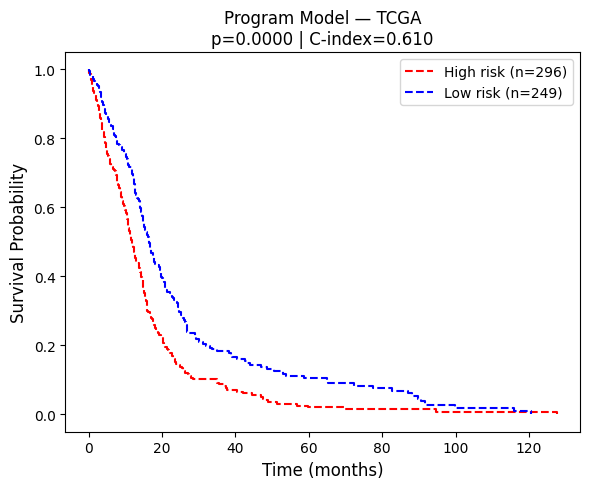

In [38]:
import pickle
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index

# ── Input matrices ─────────────────────────────────────────────────────────────
X    = prog_act_final.T
y    = guan_srv_aligned['GuanScore']
clin = guan_srv_aligned[['OS_MONTHS', 'OS_STATUS']]

# ── Fit on all TCGA patients ───────────────────────────────────────────────────
# alpha=5 selected empirically: miner's optimize_parameters_ridge optimises AUC
# on binary labels, which collapses predictions at high alpha and is inconsistent
# with the regression objective. alpha=5 gives best KM separation with meaningful
# prediction variance. Paper trains on TCGA and validates on Gravendeel/XCELSIOR.
model_prog_final = Ridge(alpha=5).fit(X, y)

with open(os.path.join(matrices_dir, "program_model_ridge.pkl"), 'wb') as f:
    pickle.dump(model_prog_final, f)

# ── Evaluate ───────────────────────────────────────────────────────────────────
pred_full = model_prog_final.predict(X)
ci_full   = concordance_index(clin['OS_MONTHS'], -pred_full, clin['OS_STATUS'])
print(f"C-index (TCGA, in-sample): {ci_full:.4f}")

high_idx = pred_full > 0.5
low_idx  = pred_full <= 0.5
high_srv = guan_srv_aligned[high_idx]
low_srv  = guan_srv_aligned[low_idx]

lr = logrank_test(high_srv['OS_MONTHS'], low_srv['OS_MONTHS'],
                  high_srv['OS_STATUS'], low_srv['OS_STATUS'])

print(f"High risk n={high_idx.sum()}, mOS={high_srv['OS_MONTHS'].median():.1f} months ({high_srv['OS_MONTHS'].median()*30.4:.0f} days)")
print(f"Low risk  n={low_idx.sum()},  mOS={low_srv['OS_MONTHS'].median():.1f} months ({low_srv['OS_MONTHS'].median()*30.4:.0f} days)")
print(f"Logrank p={lr.p_value:.4f}")
print(f"Paper Figure 4B: TCGA mOS 362 vs 548 days, p=0.027")

# ── KM curve ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
KaplanMeierFitter().fit(high_srv['OS_MONTHS'], high_srv['OS_STATUS'],
    label=f'High risk (n={high_idx.sum()})').plot_survival_function(
    ax=ax, ci_show=False, color='red', linestyle='--')
KaplanMeierFitter().fit(low_srv['OS_MONTHS'], low_srv['OS_STATUS'],
    label=f'Low risk (n={low_idx.sum()})').plot_survival_function(
    ax=ax, ci_show=False, color='blue', linestyle='--')

ax.set_xlabel("Time (months)", fontsize=12)
ax.set_ylabel("Survival Probability", fontsize=12)
ax.set_title(f"Program Model — TCGA\np={lr.p_value:.4f} | C-index={ci_full:.3f}", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(matrices_dir, "km_program_model_tcga.pdf"), dpi=300)
plt.show()

In [39]:
# Final program model: train on all TCGA
model_prog_final = Ridge(alpha=5).fit(X, y)

# Save model
import pickle
with open(os.path.join(matrices_dir, "program_model_ridge.pkl"), 'wb') as f:
    pickle.dump(model_prog_final, f)

print("Program model saved.")
print(f"Training C-index: {concordance_index(guan_srv_aligned['OS_MONTHS'], -model_prog_final.predict(X), guan_srv_aligned['OS_STATUS']):.4f}")

Program model saved.
Training C-index: 0.6096
